In [1]:
import numpy as np
import pandas as pd

Iris = pd.read_csv("iris_dataset.csv")
Iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [2]:
from sklearn.preprocessing import StandardScaler
Iris_standard = pd.DataFrame(StandardScaler().fit_transform(Iris.iloc[:, 0:4]), columns = Iris.columns[:-1])
Iris_standard

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.032057,-1.341272,-1.312977
1,-1.143017,-0.124958,-1.341272,-1.312977
2,-1.385353,0.337848,-1.398138,-1.312977
3,-1.506521,0.106445,-1.284407,-1.312977
4,-1.021849,1.263460,-1.341272,-1.312977
...,...,...,...,...
145,1.038005,-0.124958,0.819624,1.447956
146,0.553333,-1.281972,0.705893,0.922064
147,0.795669,-0.124958,0.819624,1.053537
148,0.432165,0.800654,0.933356,1.447956


# Dimension Reductions

In [3]:
import umap
umap_reducer = umap.UMAP(n_neighbors = 15, n_components = 2) # by default 2 components
umap_embedding = umap_reducer.fit_transform(Iris_standard)
umap_Iris_embedded = pd.DataFrame(umap_embedding, columns = ["Dim1", "Dim2"])
umap_Iris_embedded["Class"] = Iris["target"]
umap_Iris_embedded

,Dim1,Dim2,Class
0,3.244457,12.207879,Iris-setosa
1,6.829882,11.152929,Iris-setosa
2,6.257934,11.445799,Iris-setosa
3,6.362422,11.389404,Iris-setosa
4,3.045934,12.340738,Iris-setosa
...,...,...,...
145,8.885570,0.999649,Iris-virginica
146,6.384837,-0.389333,Iris-virginica
147,8.263535,0.697542,Iris-virginica
148,9.397426,0.216708,Iris-virginica


In [4]:
from sklearn.manifold import TSNE
tsne_reducer = TSNE(n_components = 2)
tsne_embedding = tsne_reducer.fit_transform(Iris_standard)
tsne_Iris_embedded = pd.DataFrame(tsne_embedding, columns = ["Dim1", "Dim2"])
tsne_Iris_embedded["Class"] = Iris["target"]
tsne_Iris_embedded

C:\Users\flash\anaconda3\envs\ML_Pytorch\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


,Dim1,Dim2,Class
0,-26.291174,-0.150485,Iris-setosa
1,-22.338976,-0.719800,Iris-setosa
2,-23.531496,0.158853,Iris-setosa
3,-22.728727,0.294416,Iris-setosa
4,-26.784008,-0.715555,Iris-setosa
...,...,...,...
145,12.879957,-0.413611,Iris-virginica
146,8.002160,-1.349460,Iris-virginica
147,11.793601,-0.040397,Iris-virginica
148,13.518338,-2.075937,Iris-virginica


In [5]:
from sklearn.decomposition import PCA
pca_reducer = PCA(n_components = 2)
pca_embedding = pca_reducer.fit_transform(Iris_standard)
pca_Iris_embedded = pd.DataFrame(pca_embedding, columns = ["Dim1", "Dim2"])
pca_Iris_embedded["Class"] = Iris["target"]
pca_Iris_embedded

,Dim1,Dim2,Class
0,-2.264542,0.505704,Iris-setosa
1,-2.086426,-0.655405,Iris-setosa
2,-2.367950,-0.318477,Iris-setosa
3,-2.304197,-0.575368,Iris-setosa
4,-2.388777,0.674767,Iris-setosa
...,...,...,...
145,1.870522,0.382822,Iris-virginica
146,1.558492,-0.905314,Iris-virginica
147,1.520845,0.266795,Iris-virginica
148,1.376391,1.016362,Iris-virginica


In [6]:
reducers_dict = {"UMAP": umap_Iris_embedded,
                "TSNE": tsne_Iris_embedded,
                "PCA": pca_Iris_embedded}

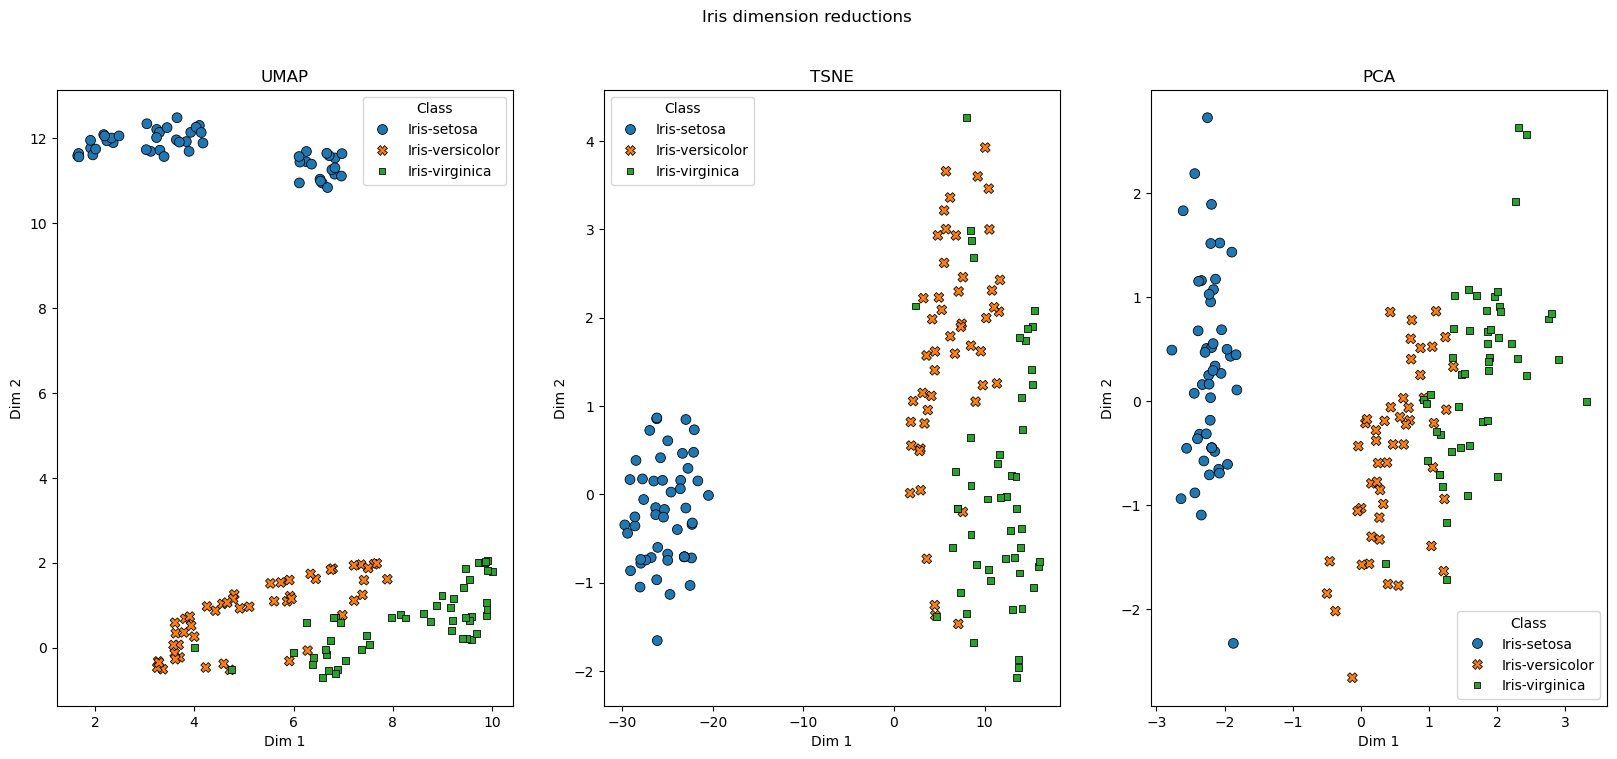

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize = (20, 8))
for i, (name, data) in enumerate(reducers_dict.items()):
    ax = fig.add_subplot(1, 3, i+1)
    sns.scatterplot(data, x = "Dim1", y = "Dim2", hue = "Class", style = "Class", s = 50, edgecolor = "black", ax = ax)
    ax.set_title(name)
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")
fig.suptitle("Iris dimension reductions")    
plt.show()

# Clustering approaches

## K-means

C:\Users\flash\anaconda3\envs\ML_Pytorch\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\flash\anaconda3\envs\ML_Pytorch\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\flash\anaconda3\envs\ML_Pytorch\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


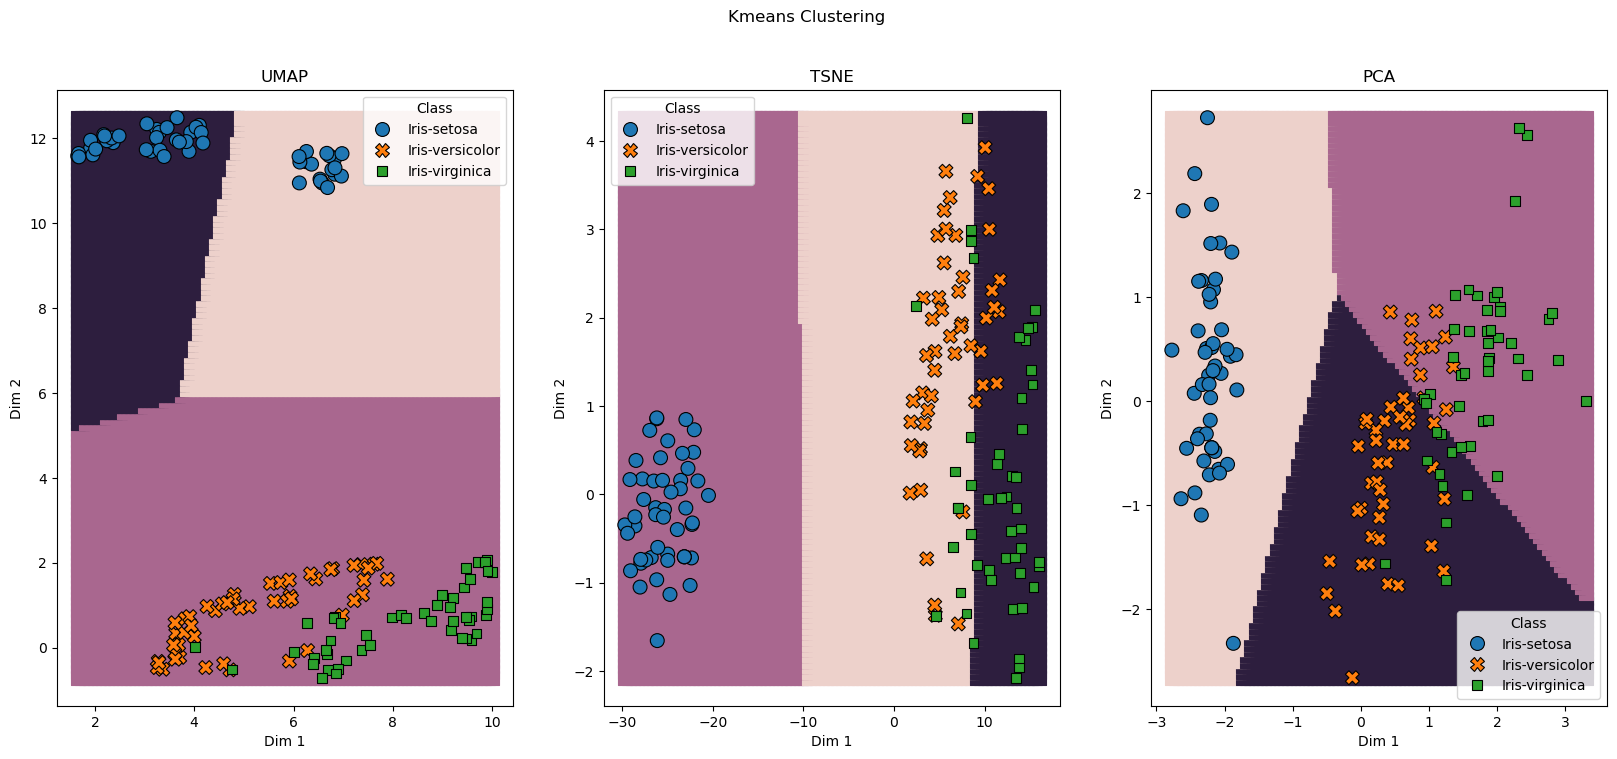

In [8]:
from sklearn.cluster import KMeans

pred_size = 100
marker_size = 100

fig = plt.figure(figsize = (20, 8))
for i, (name, data) in enumerate(reducers_dict.items()):
    kmeans_clustering = KMeans(n_clusters = 3)
    kmeans_clustering.fit(data.iloc[:, :-1].to_numpy())

    mesh_x_min = np.min(data.loc[:, "Dim1"])
    mesh_x_max = np.max(data.loc[:, "Dim1"])
    mesh_y_min = np.min(data.loc[:, "Dim2"])
    mesh_y_max = np.max(data.loc[:, "Dim2"])
    mesh_y = np.linspace(mesh_y_min, mesh_y_max, pred_size)
    mesh_x = np.linspace(mesh_x_min, mesh_x_max, pred_size)
    
    mesh_xv, mesh_yv = np.meshgrid(mesh_x, mesh_y)
    mesh = np.concatenate((mesh_xv.reshape(pred_size**2, 1), mesh_yv.reshape(pred_size**2, 1)), axis = 1)

    mesh_pred = kmeans_clustering.predict(mesh)[:, None]
    mesh = pd.DataFrame(np.concatenate((mesh, mesh_pred), axis = 1))
    mesh.columns = ["Dim1", "Dim2", "Pred"]

    
    ax = fig.add_subplot(1, 3, i+1)
    sns.scatterplot(mesh, x = "Dim1", y = "Dim2", hue = "Pred", s = marker_size, ax = ax, alpha = 1, edgecolor = None, marker = "s", legend = None)
    sns.scatterplot(data, x = "Dim1", y = "Dim2", hue = "Class", style = "Class", s = marker_size, edgecolor = "black", ax = ax)
    ax.set_title(name)
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")
fig.suptitle("Kmeans Clustering")    
plt.show()

## Hierarchical

In [9]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

### Linakge

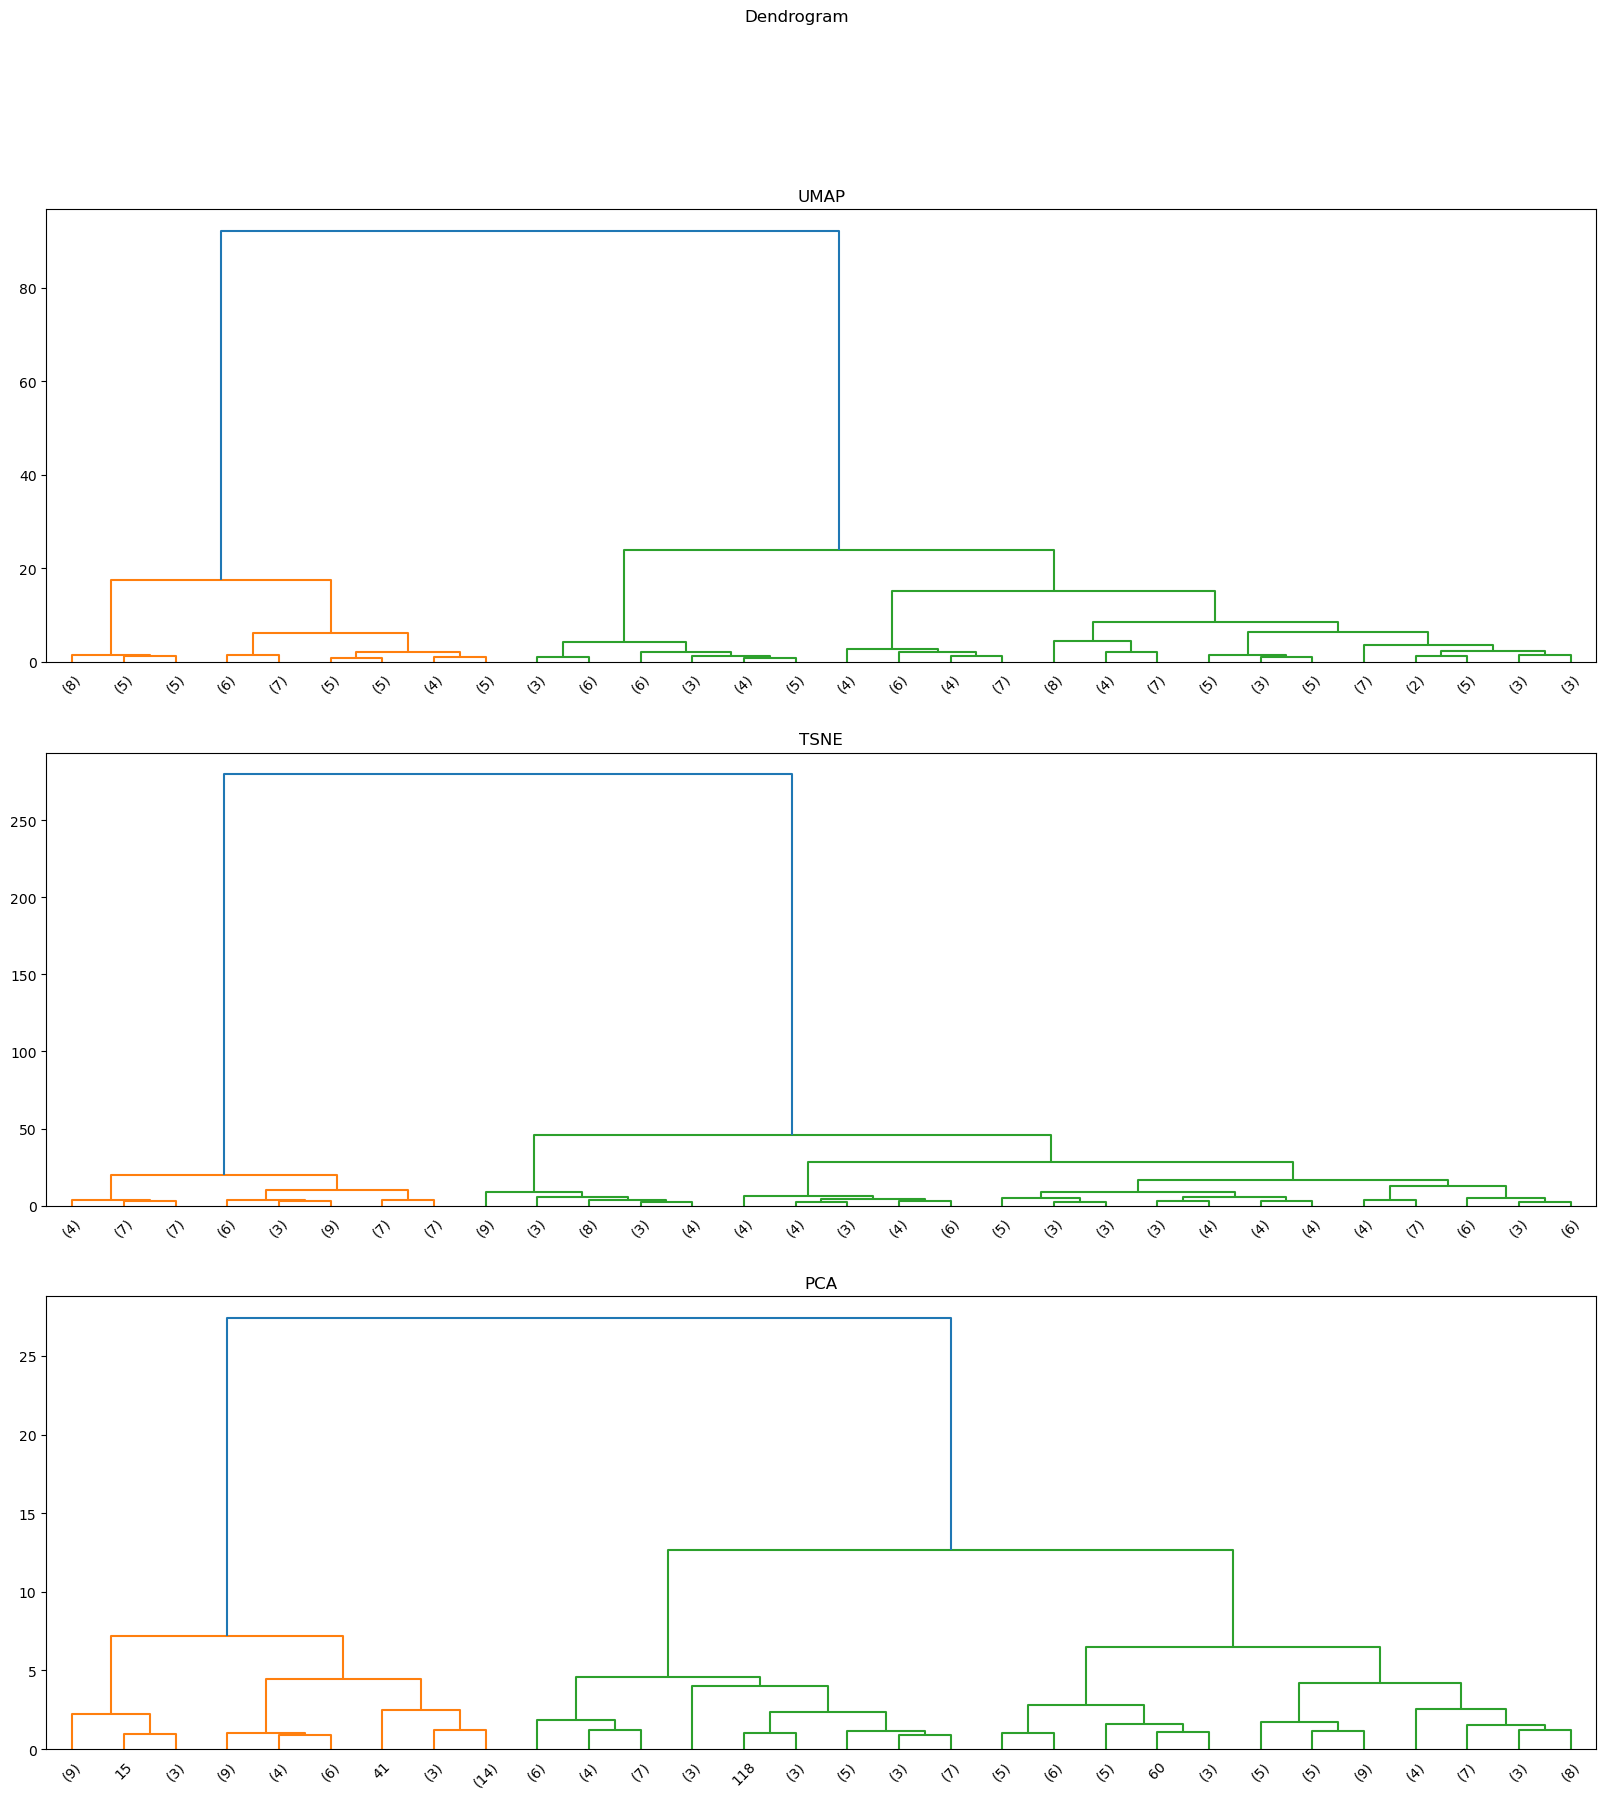

In [10]:
fig = plt.figure(figsize = (20, 20))
for i, (name, data) in enumerate(reducers_dict.items()):
    linked = linkage(data.iloc[:, :-1], method='ward')
    ax = fig.add_subplot(3, 1, i+1)
    dendrogram(linked, ax = ax, truncate_mode = "lastp")
    ax.set_title(name)
fig.suptitle("Dendrogram")    
plt.show()

### Agglomerative

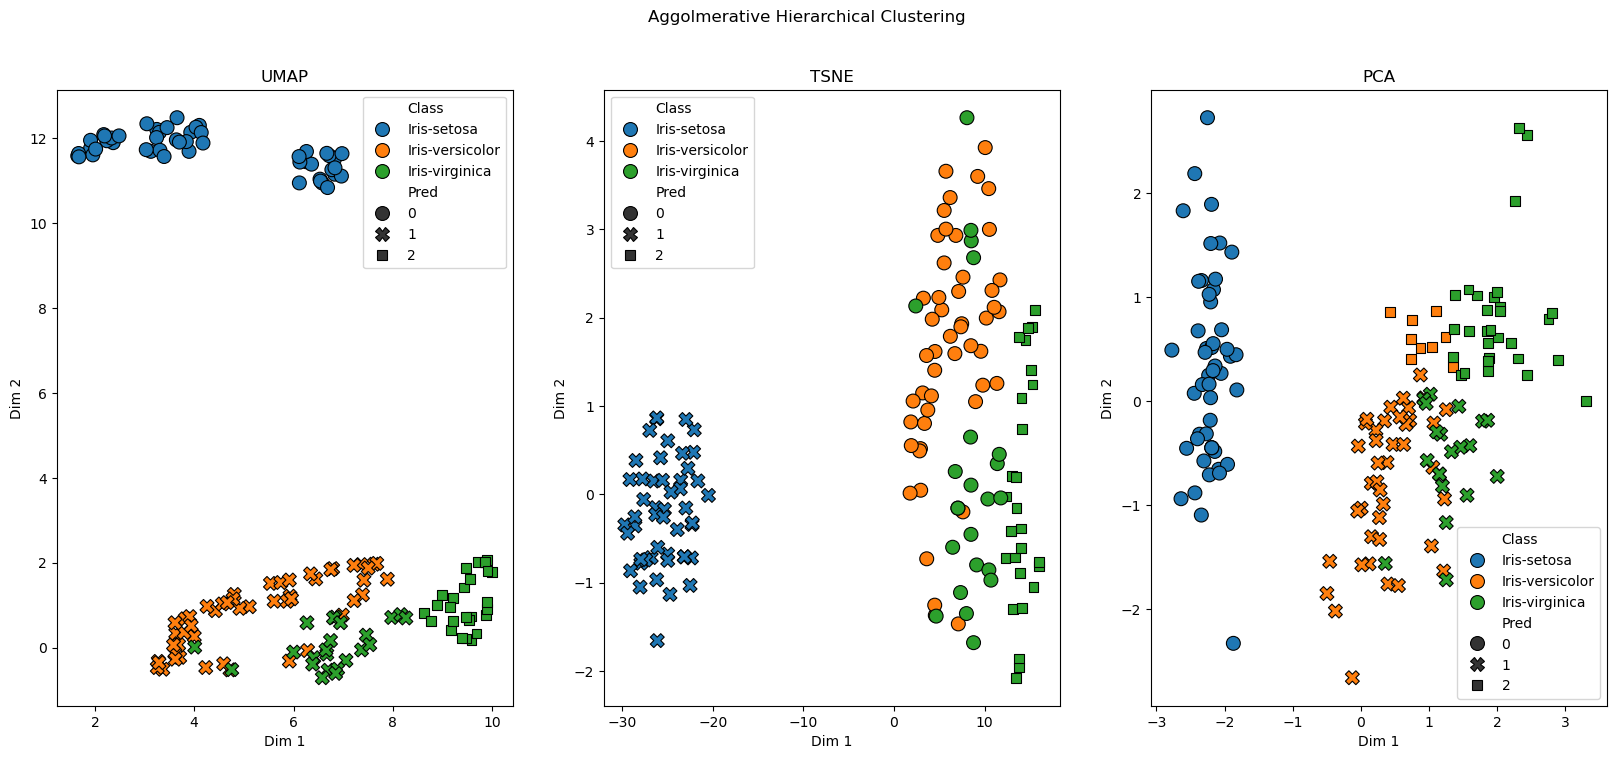

In [11]:
pred_size = 100
marker_size = 100

fig = plt.figure(figsize = (20, 8))
for i, (name, data) in enumerate(reducers_dict.items()):
    agglo_clustering = AgglomerativeClustering(n_clusters=3, linkage='ward')
    pred = agglo_clustering.fit_predict(data.iloc[:, :-1].to_numpy())
    data_copied = data.copy()
    data_copied["Pred"] = pred

    ax = fig.add_subplot(1, 3, i+1)
    sns.scatterplot(data_copied, x = "Dim1", y = "Dim2", hue = "Class", style = "Pred", s = marker_size, edgecolor = "black", ax = ax)
    ax.set_title(name)
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")
fig.suptitle("Aggolmerative Hierarchical Clustering")    
plt.show()



## DBSCAN

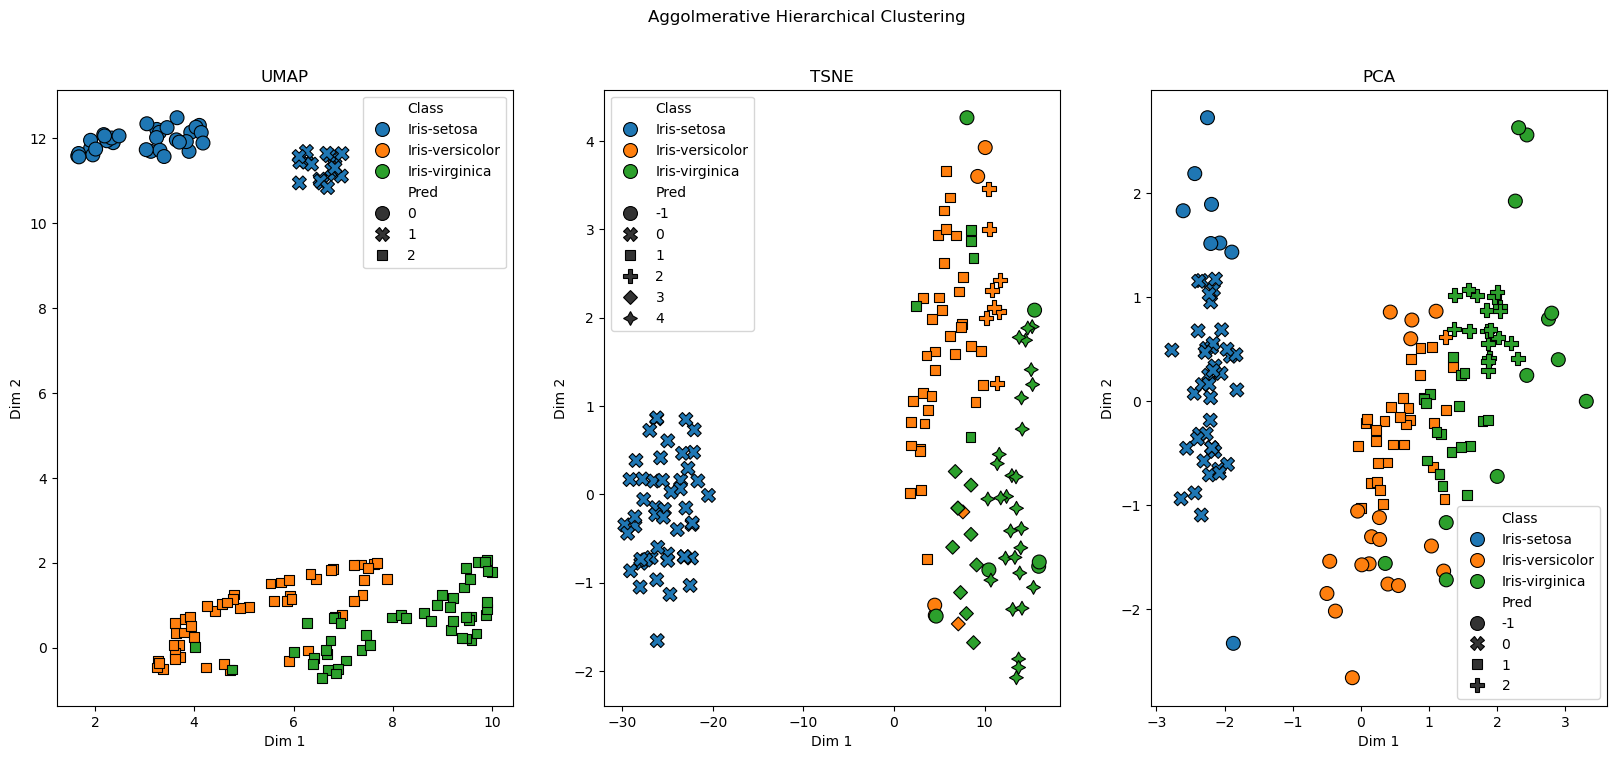

In [31]:
from sklearn.cluster import DBSCAN

pred_size = 100
marker_size = 100

settings = {"UMAP": {"eps": 1.0, "min_samples": 10},
           "TSNE": {"eps": 1.5, "min_samples": 10},
           "PCA": {"eps": 0.5, "min_samples": 15}}

fig = plt.figure(figsize = (20, 8))
for i, (name, data) in enumerate(reducers_dict.items()):
    setting = settings[name]
    dbscan_clustering = DBSCAN(eps = setting["eps"], min_samples = setting["min_samples"])
    dbscan_clustering.fit(data.iloc[:, :-1].to_numpy())
    pred = dbscan_clustering.fit_predict(data.iloc[:, :-1].to_numpy())
    data_copied = data.copy()
    data_copied["Pred"] = pred

    ax = fig.add_subplot(1, 3, i+1)
    sns.scatterplot(data_copied, x = "Dim1", y = "Dim2", hue = "Class", style = "Pred", s = marker_size, edgecolor = "black", ax = ax)
    ax.set_title(name)
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")
fig.suptitle("Aggolmerative Hierarchical Clustering")    
plt.show()

